In [2]:
import os
import wbgapi as wb
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt

# I define the project root to ensure files save in the correct directories
project_root = os.path.abspath('..')
raw_dir = os.path.join(project_root, 'data', 'raw')
processed_dir = os.path.join(project_root, 'data', 'processed')

os.makedirs(raw_dir, exist_ok=True)
os.makedirs(processed_dir, exist_ok=True)

In [3]:
# I define a dictionary mapping World Bank indicator codes to readable column names
indicators = {
    'NY.GDP.PCAP.CD': 'gdp_per_capita',       # target variable (Y)
    'NE.TRD.GNFS.ZS': 'trade_openness',       # imports + exports (% of GDP)
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_inflows',    # foreign direct investment (% of GDP)
    'NE.GDI.TOTL.ZS': 'capital_formation',    # physical capital (% of GDP)
    'SP.DYN.LE00.IN': 'life_expectancy',      # human capital / health (Years)
    'SL.TLF.CACT.ZS': 'labor_force_part',     # labor force participation rate (%)
    'GB.XPD.RSDV.GD.ZS': 'rnd_expenditure',   # innovation / R&D (% of GDP)
    'SP.POP.GROW': 'population_growth',       # demographics (Annual %)
    'FP.CPI.TOTL.ZG': 'inflation_rate'        # macro stability (Annual %)
}

print("fetching data from the World Bank API for the year 2019...")

# fetching the data for 2019 to avoid macroeconomic anomalies caused by the 2020 pandemic
df_raw = wb.data.DataFrame(indicators.keys(), time=2019, labels=True)

#cleaning up the index and column names
df_raw = df_raw.reset_index()
df_raw = df_raw.rename(columns=indicators)
df_raw = df_raw.rename(columns={'economy': 'country_code', 'Country': 'country_name'})

# I save the completely raw, untouched data
raw_path = os.path.join(raw_dir, 'world_bank_2019_raw.csv')
df_raw.to_csv(raw_path, index=False)

print(f"Data fetched for {len(df_raw)} regions and saved.")

fetching data from the World Bank API for the year 2019...
Data fetched for 266 regions and saved.


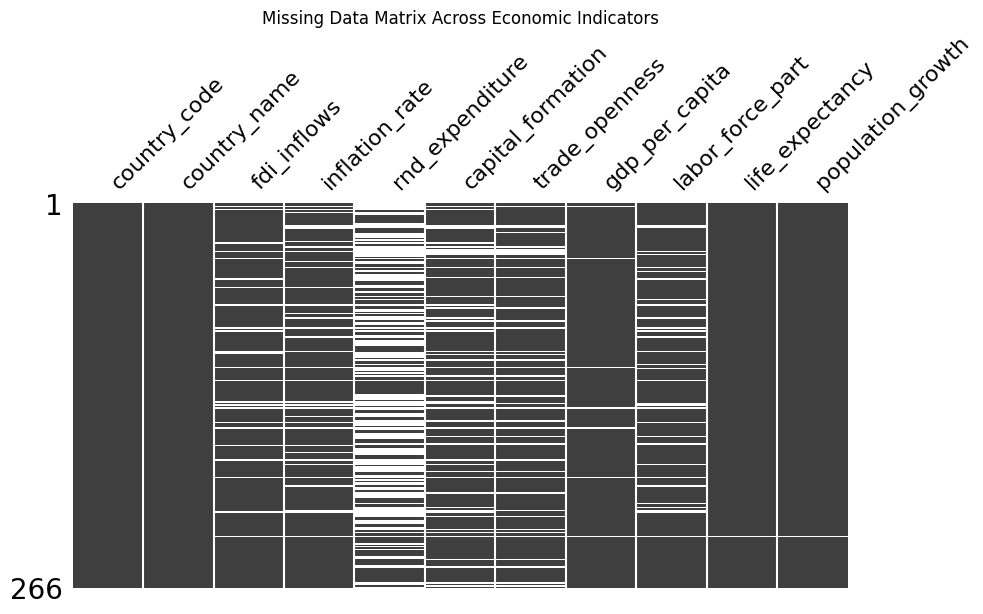

Percentage of missing data per feature:
country_code          0.00
country_name          0.00
fdi_inflows           9.02
inflation_rate       13.16
rnd_expenditure      52.26
capital_formation    19.17
trade_openness       15.79
gdp_per_capita        2.63
labor_force_part     11.65
life_expectancy       0.38
population_growth     0.38
dtype: float64


In [4]:
# visualise the missing data using a matrix plot to identify patterns of absence
msno.matrix(df_raw, figsize=(10, 5), sparkline=False)
plt.title("Missing Data Matrix Across Economic Indicators")
plt.show()

# printing the exact percentage of missing values per column
missing_percentages = df_raw.isnull().sum() / len(df_raw) * 100
print("Percentage of missing data per feature:")
print(missing_percentages.round(2))

Now cleaning the data and imputation

In [6]:
# I create a copy of the dataframe for processing
df_clean = df_raw.copy()

# I drop aggregate regions (like 'World' or 'Euro area') so I only analyse distinct countries
# Aggregate regions often lack specific feature data, acting as outliers in the data
df_clean = df_clean.dropna(subset=['gdp_per_capita'])

# I drop R&D expenditure entirely if the missing percentage is too high (often > 50%)
# In econometrics, imputing more than half of a variable would create severe bias
if missing_percentages['rnd_expenditure'] > 40:
    print("Dropping rnd_expenditure due to high missingness.")
    df_clean = df_clean.drop(columns=['rnd_expenditure'])

# For the remaining independent variables, I use median imputation to fill small gaps
# I use the median rather than the mean to avoid skewing from extreme macroeconomic outliers
numeric_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns

for col in numeric_cols:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)

# I save the cleaned, strict matrix ready for mathematical modeling
processed_path = os.path.join(processed_dir, 'world_bank_2019_cleaned.csv')
df_clean.to_csv(processed_path, index=False)

print(f"Final cleaned dataset contains {len(df_clean)} countries and {len(df_clean.columns)} columns.")

Dropping rnd_expenditure due to high missingness.
Final cleaned dataset contains 259 countries and 10 columns.
